In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
from sklearn.model_selection import train_test_split
from scipy import stats
from scipy.stats import wasserstein_distance, epps_singleton_2samp
from tqdm import tqdm

COUNTS
Total RBC count: 4155
Total WBC count: 372
Total Platelet count: 361
Clearly there is a class imbalance in the dataset. RBCs are the most abundant, followed by WBCs and Platelets.


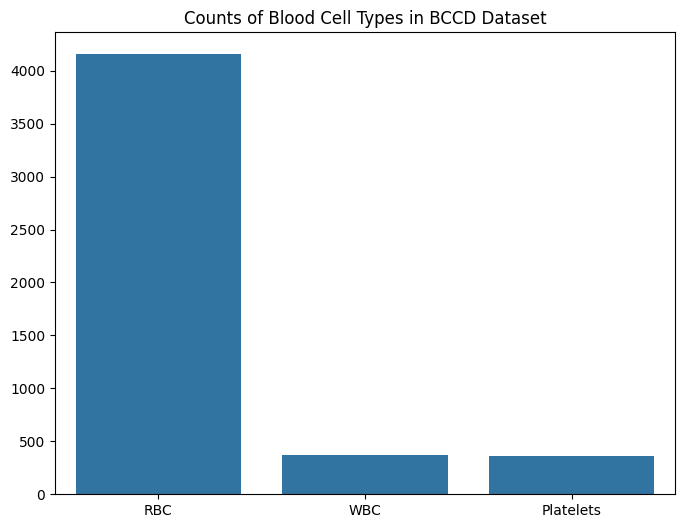

IMAGES CONTAINING EACH BLOOD CELL TYPE
Images with RBCs: 349
Images with WBCs: 358
Images with Platelets: 201
Images with no RBCs: 15
Images with no WBCs: 6
Images with no Platelets: 163


Text(0.5, 1.0, 'Distribution of Platelet Counts per Image')

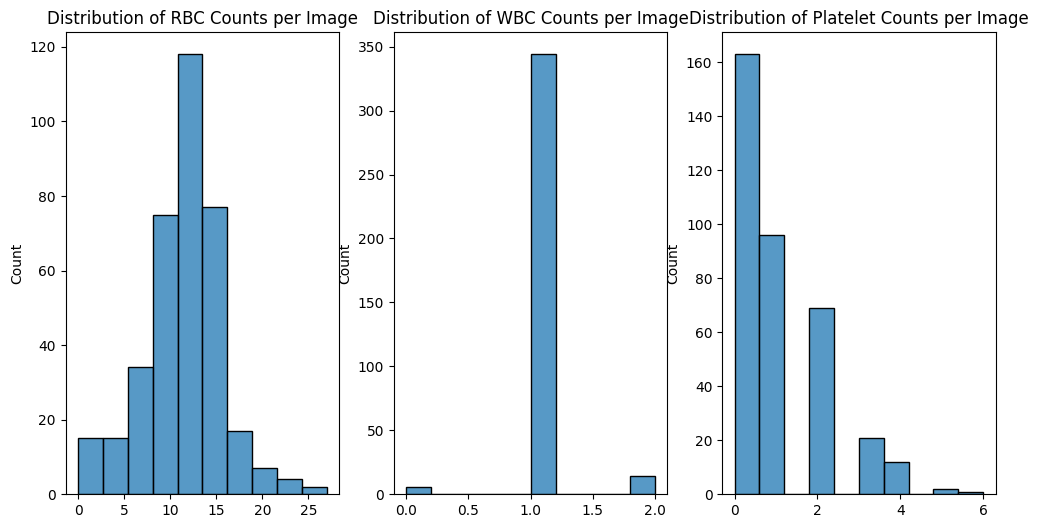

In [3]:
# Getting Annotations and Exploring Blood Cell counts. This is to find out if the dataset is balanced or not.
anno_dir = '../data/BCCD/Annotations/'
files_in_anno_dir = os.listdir(anno_dir)

# Parsing the XML files and converting them to JSON format for easier analysis
json_data = []
for f in files_in_anno_dir:
    with open(os.path.join(anno_dir, f)) as xml_file:
        json_data.append({f[:-4]: {}})
        tree = ET.parse(xml_file)
        root = tree.getroot()
        names = []
        rbc_count = 0
        wbc_count = 0
        platelet_count = 0
        for b in root.findall('object'):
            name = b.find('name').text
            if name.lower() == 'RBC'.lower():
                rbc_count += 1
                new_key = name + str(rbc_count)
            elif name.lower() == 'WBC'.lower():
                wbc_count += 1
                new_key = name + str(wbc_count)
            elif name.lower() == 'Platelets'.lower():
                platelet_count += 1
                new_key = name + str(platelet_count)
            bounding_box = b.find('bndbox')
            xmin = int(bounding_box.find('xmin').text)
            xmax = int(bounding_box.find('xmax').text)
            ymin = int(bounding_box.find('ymin').text)
            ymax = int(bounding_box.find('ymax').text)
            trunc = int(b.find('truncated').text)
            difficult = int(b.find('difficult').text)
            names.append(name)
            json_data[-1][f[:-4]][new_key] = {
                'name': name,
                'xmin': xmin,
                'xmax': xmax,
                'ymin': ymin,
                'ymax': ymax,
                'truncated': trunc,
                'difficult': difficult
            }
        json_data[-1][f[:-4]]['counts'] = {
            'RBC': rbc_count,
            'WBC': wbc_count,
            'Platelets': platelet_count
        }

#Extracting the counts of each blood cell type from the JSON data
rbc_counts = []
wbc_counts = []
platelet_counts = []
for data in json_data:
    for key in data.keys():
        rbc_counts.append(data[key]['counts']['RBC'])
        wbc_counts.append(data[key]['counts']['WBC'])
        platelet_counts.append(data[key]['counts']['Platelets'])
rbc_sum = np.sum(rbc_counts)
wbc_sum = np.sum(wbc_counts)
platelet_sum = np.sum(platelet_counts)

print('COUNTS')
print(f'Total RBC count: {rbc_sum}')
print(f'Total WBC count: {wbc_sum}')
print(f'Total Platelet count: {platelet_sum}')

# Visualizing the TOTAL counts of each blood cell type using a bar plot
cell_types = ['RBC', 'WBC', 'Platelets']
counts = [rbc_sum, wbc_sum, platelet_sum]
plt.figure(figsize=(8, 6))
sns.barplot(x=cell_types, y=counts)
plt.title('Counts of Blood Cell Types in BCCD Dataset')
print("Clearly there is a class imbalance in the dataset. RBCs are the most abundant, followed by WBCs and Platelets.")
plt.show()

#However, this does make sense...there should be more RBCs than WBCs and Platelets in a blood smear. A better
# way to look at the data is to see how many images contain each type of blood cell. This will give us a better idea of how
# balanced the dataset is in terms of the number of images containing each type of blood cell.

images_with_rbc = 0
images_with_wbc = 0
images_with_platelets = 0
images_with_no_rbc = 0
images_with_no_wbc = 0
images_with_no_platelets = 0
for data in json_data:
    for key in data.keys():
        if data[key]['counts']['RBC'] > 0:
            images_with_rbc += 1
        if data[key]['counts']['WBC'] > 0:
            images_with_wbc += 1
        if data[key]['counts']['Platelets'] > 0:
            images_with_platelets += 1
        if data[key]['counts']['RBC'] == 0:
            images_with_no_rbc += 1
        if data[key]['counts']['WBC'] == 0:
            images_with_no_wbc += 1
        if data[key]['counts']['Platelets'] == 0:
            images_with_no_platelets += 1

print('IMAGES CONTAINING EACH BLOOD CELL TYPE')
print(f'Images with RBCs: {images_with_rbc}')
print(f'Images with WBCs: {images_with_wbc}')
print(f'Images with Platelets: {images_with_platelets}')
print(f'Images with no RBCs: {images_with_no_rbc}')
print(f'Images with no WBCs: {images_with_no_wbc}')
print(f'Images with no Platelets: {images_with_no_platelets}')

# in this piece of code, I plot the distribution of RBC, WBC, and Platelet counts per image respectively.
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.histplot(rbc_counts, bins=10)
plt.title('Distribution of RBC Counts per Image')
plt.subplot(1, 3, 2)
sns.histplot(wbc_counts, bins=10)
plt.title('Distribution of WBC Counts per Image')
plt.subplot(1, 3, 3)
sns.histplot(platelet_counts, bins=10)
plt.title('Distribution of Platelet Counts per Image')

In [4]:
# Cell for appropriate train-test split. The dataset is small, so we will use 70% for training and 15% each for validation and testing. 
# The split will be done in a stratified manner to ensure that the class distribution is maintained across the splits.
# Strategy being used: oversampling rare classes and using data augmentation in-line later 
# to increase the number of samples for the rare classes.

all_image_keys = [key for data in json_data for key in data.keys()]
num_cells_per_image = np.array([rbc_counts, wbc_counts, platelet_counts]).T
print(num_cells_per_image)
print(num_cells_per_image.shape)




[[10  1  1]
 [13  1  1]
 [10  1  2]
 ...
 [11  1  0]
 [ 0  1  0]
 [11  1  0]]
(364, 3)


Initial train loss: 0.2811
Initial test loss: 0.6492
Initial Combined Loss: 0.9303
START


100%|██████████| 15000/15000 [00:01<00:00, 7533.49it/s]
/Users/kjanson/bccd_object_detection/venv/lib/python3.9/site-packages/scipy/stats/_hypotests.py:119: RuntimeWarning: divide by zero encountered in divide
  ts = np.reshape(t, (-1, 1)) / sigma
/Users/kjanson/bccd_object_detection/venv/lib/python3.9/site-packages/scipy/stats/_hypotests.py:122: RuntimeWarning: invalid value encountered in multiply
  gx = np.vstack((np.cos(ts*x), np.sin(ts*x))).T  # shape = (nx, 2*len(t))
/Users/kjanson/bccd_object_detection/venv/lib/python3.9/site-packages/scipy/stats/_hypotests.py:122: RuntimeWarning: invalid value encountered in cos
  gx = np.vstack((np.cos(ts*x), np.sin(ts*x))).T  # shape = (nx, 2*len(t))
/Users/kjanson/bccd_object_detection/venv/lib/python3.9/site-packages/scipy/stats/_hypotests.py:122: RuntimeWarning: invalid value encountered in sin
  gx = np.vstack((np.cos(ts*x), np.sin(ts*x))).T  # shape = (nx, 2*len(t))
/Users/kjanson/bccd_object_detection/venv/lib/python3.9/site-packages/sc


Final Train Loss: 0.0424
Final Test Loss: 0.0978
Final Combined Loss: 0.1402

P-value for RBC train distribution vs original distribution: 0.998908
P-value for RBC test distribution vs original distribution: 0.995892
p-value not found for train WBC distributions 
p-value not found for test WBC distributions 
P-value for Platelet train distribution vs original distribution: 0.9996
P-value for Platelet test distribution vs original distribution: 0.9871


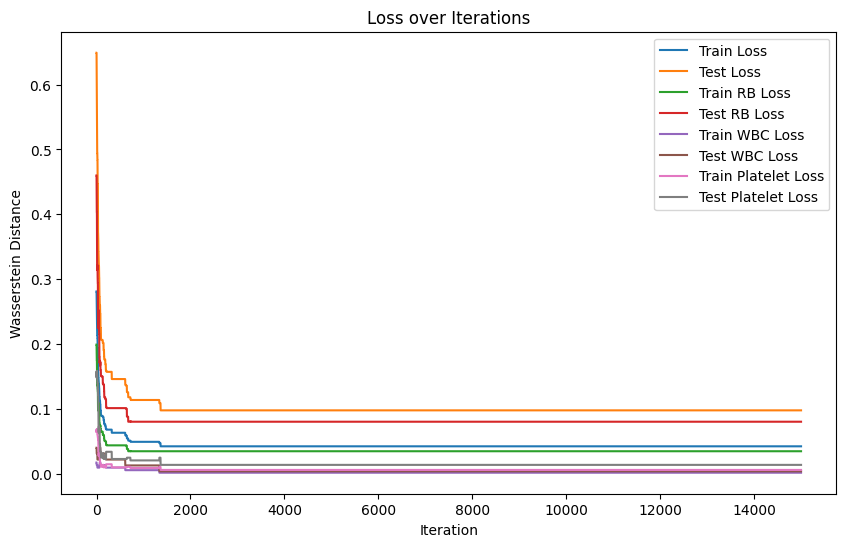

<Figure size 640x480 with 0 Axes>

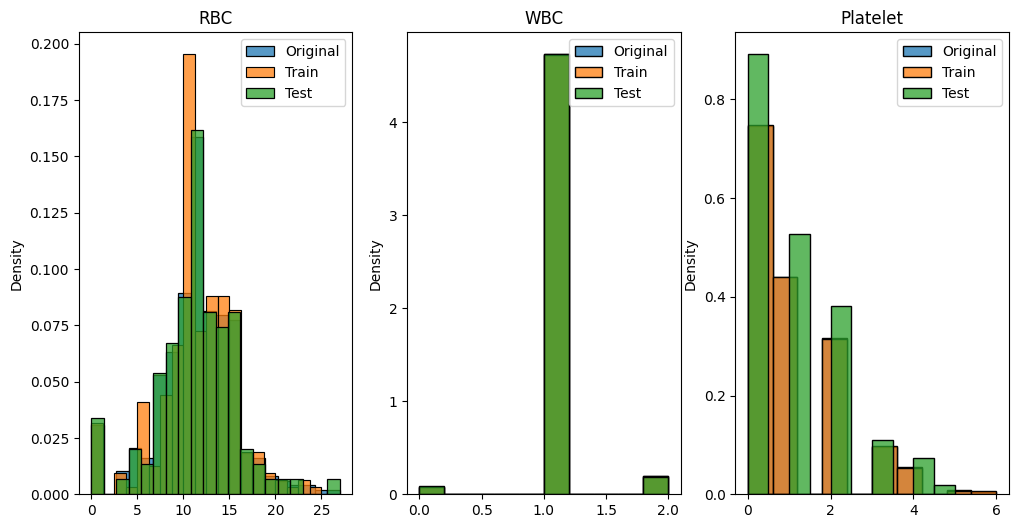

In [61]:
def compute_loss(cell_count, train_idx, test_idx):
    """
    Compute a loss that measures how different the count distributions are.
    We want this loss to be as small as possible.
    
    Higher Wasserstein distances = more different distributions = worse.
    We therefore use the Wasserstein distance directly as a loss (lower is better).
    """
    
    train_loss = 0.0
    test_loss = 0.0

    def pair_loss(counts, split_idx):
        #a here is the full array of counts (the ground truth distribution)
        # b is the counts for the split we are comparing against

        a = np.asarray(counts).copy()
        b = np.asarray(counts)[split_idx]
        return wasserstein_distance(a, b)   # already a distance → lower is better
    
    train_loss += pair_loss(cell_count, train_idx)
    test_loss += pair_loss(cell_count, test_idx)
    return train_loss, test_loss

def optimize_split(cell_count_rb, cell_count_wb, cell_count_pl,
                   train_idx, test_idx, n_iterations=9000, verbose=True):
    """
    Hill-climbing optimizer.
    
    Starts from the given initial split and repeatedly tries random swaps.
    Only accepts a swap if it reduces the loss.
    """
    # Make local copies so we do not modify the original lists
    train_idx = list(train_idx)
    test_idx  = list(test_idx)
    cell_count_rb = np.asarray(cell_count_rb).copy()
    cell_count_wb = np.asarray(cell_count_wb).copy()
    cell_count_pl = np.asarray(cell_count_pl).copy()

    current_train_loss_rb, current_test_loss_rb = compute_loss(cell_count_rb, train_idx, test_idx)
    current_train_loss_wb, current_test_loss_wb = compute_loss(cell_count_wb, train_idx, test_idx)
    current_train_loss_pl, current_test_loss_pl = compute_loss(cell_count_pl, train_idx, test_idx)

    current_combined_loss_train = current_train_loss_rb + current_train_loss_wb + current_train_loss_pl
    current_combined_loss_test = current_test_loss_rb + current_test_loss_wb + current_test_loss_pl
    current_combined_loss = current_combined_loss_train + current_combined_loss_test

    all_train_losses_rb = [current_train_loss_rb]
    all_test_losses_rb = [current_test_loss_rb]
    all_train_losses_wb = [current_train_loss_wb]
    all_test_losses_wb = [current_test_loss_wb]
    all_train_losses_pl = [current_train_loss_pl]
    all_test_losses_pl = [current_test_loss_pl]
    all_train_losses = [current_combined_loss_train]
    all_test_losses = [current_combined_loss_test]

    if verbose:
        # print(f"Initial RBC train loss: {current_train_loss_rb:.4f}")
        # print(f"Initial RBC test loss: {current_test_loss_rb:.4f}")
        # print(f"Initial WBC train loss: {current_train_loss_wb:.4f}")
        # print(f"Initial WBC test loss: {current_test_loss_wb:.4f}")
        # print(f"Initial PL train loss: {current_train_loss_pl:.4f}")
        # print(f"Initial PL test loss: {current_test_loss_pl:.4f}")
        print(f"Initial train loss: {current_combined_loss_train:.4f}")
        print(f"Initial test loss: {current_combined_loss_test:.4f}")
        print(f"Initial Combined Loss: {current_combined_loss:.4f}")
        print("START")

    for iteration in tqdm(range(n_iterations)):

        

        # Randomly pick one image from each of the two sets
        i = np.random.randint(len(cell_count_rb[train_idx]))
        j = np.random.randint(len(cell_count_rb[test_idx]))
        

        # Remember the original image IDs so we can undo the swap if needed
        # Correct version
        idx_a = train_idx[i]          # actual image index
        idx_b = test_idx[j]           # actual image index

        # Swap the indices
        train_idx[i] = idx_b
        test_idx[j] = idx_a

        new_train_loss_rb, new_test_loss_rb = compute_loss(cell_count_rb, train_idx, test_idx)
        new_train_loss_wb, new_test_loss_wb = compute_loss(cell_count_wb, train_idx, test_idx)
        new_train_loss_pl, new_test_loss_pl = compute_loss(cell_count_pl, train_idx, test_idx)

        new_combined_loss_train = new_train_loss_rb + new_train_loss_wb + new_train_loss_pl
        new_combined_loss_test = new_test_loss_rb + new_test_loss_wb + new_test_loss_pl
        new_combined_loss = new_combined_loss_train + new_combined_loss_test

        
        
        if new_combined_loss < (current_combined_loss):
            # Improvement! Keep the swap and update the current loss
            current_train_loss_rb = new_train_loss_rb
            current_test_loss_rb = new_test_loss_rb
            current_train_loss_wb = new_train_loss_wb
            current_test_loss_wb = new_test_loss_wb
            current_train_loss_pl = new_train_loss_pl
            current_test_loss_pl = new_test_loss_pl

            current_combined_loss_train = new_combined_loss_train
            current_combined_loss_test = new_combined_loss_test
            current_combined_loss = new_combined_loss

            all_train_losses_rb.append(current_train_loss_rb)
            all_test_losses_rb.append(current_test_loss_rb)
            all_train_losses_wb.append(current_train_loss_wb)
            all_test_losses_wb.append(current_test_loss_wb)
            all_train_losses_pl.append(current_train_loss_pl)
            all_test_losses_pl.append(current_test_loss_pl)
            all_train_losses.append(current_combined_loss_train)
            all_test_losses.append(current_combined_loss_test)

        else:
            # Revert the swap
            train_idx[i] = idx_a
            test_idx[j] = idx_b
            all_train_losses_rb.append(current_train_loss_rb)
            all_test_losses_rb.append(current_test_loss_rb)
            all_train_losses_wb.append(current_train_loss_wb)
            all_test_losses_wb.append(current_test_loss_wb)
            all_train_losses_pl.append(current_train_loss_pl)
            all_test_losses_pl.append(current_test_loss_pl)
            all_train_losses.append(current_combined_loss_train)
            all_test_losses.append(current_combined_loss_test)
    print()
    print(f"Final Train Loss: {current_combined_loss_train:.4f}")
    print(f"Final Test Loss: {current_combined_loss_test:.4f}")
    print(f"Final Combined Loss: {current_combined_loss:.4f}")
    return train_idx, test_idx, all_train_losses_rb,\
        all_test_losses_rb, all_train_losses_wb, all_test_losses_wb,\
        all_train_losses_pl, all_test_losses_pl, all_train_losses, all_test_losses


train_idx, test_idx = train_test_split(np.arange(len(all_image_keys)), test_size=0.3)
# val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)

train_idx = train_idx.tolist()
test_idx = test_idx.tolist()
# val_idx = val_idx.tolist()

train_idx, test_idx, all_train_losses_rb, all_test_losses_rb, all_train_losses_wb, all_test_losses_wb, all_train_losses_pl,\
all_test_losses_pl, all_train_losses, all_test_losses = optimize_split(rbc_counts, wbc_counts, platelet_counts, train_idx, test_idx, n_iterations=15000, verbose=True)


print()
_, p = epps_singleton_2samp(rbc_counts, np.array(rbc_counts)[train_idx])
print(f"P-value for RBC train distribution vs original distribution: {p:4f}")
_, p = epps_singleton_2samp(rbc_counts, np.array(rbc_counts)[test_idx])
print(f"P-value for RBC test distribution vs original distribution: {p:4f}")
try:
    _, p = epps_singleton_2samp(wbc_counts, np.array(wbc_counts)[train_idx])
    print(f"P-value for WBC train distribution vs original distribution: {p:4f}")
except np.linalg.LinAlgError:
    print('p-value not found for train WBC distributions ')

try:
    _, p = epps_singleton_2samp(wbc_counts, np.array(wbc_counts)[test_idx])
    print(f"P-value for WBC test distribution vs original distribution: {p:4f}")
except np.linalg.LinAlgError:
    print('p-value not found for test WBC distributions ')

try:
    _, p = epps_singleton_2samp(platelet_counts, np.array(platelet_counts)[train_idx])
    print(f"P-value for Platelet train distribution vs original distribution: {p:.4f}")
except np.linalg.LinAlgError:
    print('p-value not found for train Platelet distributions ')

try:
    _, p = epps_singleton_2samp(platelet_counts, np.array(platelet_counts)[test_idx])
    print(f"P-value for Platelet test distribution vs original distribution: {p:.4f}")
except np.linalg.LinAlgError:
    print('p-value not found for test Platelet distributions ')

plt.figure(figsize=(10, 6))
plt.plot(all_train_losses, label='Train Loss')
plt.plot(all_test_losses, label='Test Loss')
plt.plot(all_train_losses_rb, label = 'Train RB Loss')
plt.plot(all_test_losses_rb, label = "Test RB Loss")
plt.plot(all_train_losses_wb, label='Train WBC Loss')
plt.plot(all_test_losses_wb, label='Test WBC Loss')
plt.plot(all_train_losses_pl, label='Train Platelet Loss')
plt.plot(all_test_losses_pl, label='Test Platelet Loss')
plt.title('Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Wasserstein Distance')
plt.legend()
plt.show()

# in this piece of code, I plot the distribution of RBC, WBC, and Platelet counts per image respectively.
plt.figure()
fig, axes = plt.subplots(1, 3, figsize=(12,6))

sns.histplot(rbc_counts, bins=20, label = 'Original', stat='density', ax = axes[0])
sns.histplot(np.array(rbc_counts)[train_idx], bins = 20, label= 'Train', stat='density', ax = axes[0])
sns.histplot(np.array(rbc_counts)[test_idx], bins=20, label='Test', stat='density', ax = axes[0])
axes[0].set_title("RBC")
axes[0].legend()

plt.subplot(1,3,2)
sns.histplot(wbc_counts, bins=10, label='Original', stat='density', ax=axes[1])
sns.histplot(np.array(wbc_counts)[train_idx], bins=10, label='Train', stat='density', ax=axes[1])
sns.histplot(np.array(wbc_counts)[test_idx], bins=10, label='Test', stat='density', ax=axes[1])
axes[1].set_title("WBC")
axes[1].legend()

plt.subplot(1,3,3)
sns.histplot(platelet_counts, bins=10, label = 'Original', stat='density', ax=axes[2])
sns.histplot(np.array(platelet_counts)[train_idx], bins=10, label = "Train", stat='density', ax=axes[2])
sns.histplot(np.array(platelet_counts)[test_idx], bins=10, label='Test', stat='density', ax=axes[2])
axes[2].set_title("Platelet")
axes[2].legend()



../data/BCCD/JPEGImages/BloodImage_00315.jpg
{'name': 'RBC', 'xmin': 164, 'xmax': 297, 'ymin': 261, 'ymax': 364, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 15, 'xmax': 148, 'ymin': 66, 'ymax': 169, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 13, 'xmax': 132, 'ymin': 234, 'ymax': 333, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 239, 'xmax': 354, 'ymin': 3, 'ymax': 107, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 542, 'xmax': 640, 'ymin': 109, 'ymax': 214, 'truncated': 1, 'difficult': 0}
{'name': 'RBC', 'xmin': 441, 'xmax': 539, 'ymin': 293, 'ymax': 398, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 273, 'xmax': 383, 'ymin': 198, 'ymax': 309, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 148, 'xmax': 277, 'ymin': 129, 'ymax': 251, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 363, 'xmax': 466, 'ymin': 69, 'ymax': 160, 'truncated': 0, 'difficult': 0}
{'name': 'RBC', 'xmin': 382, 'xmax': 469, 'ymin': 190, 'ymax'

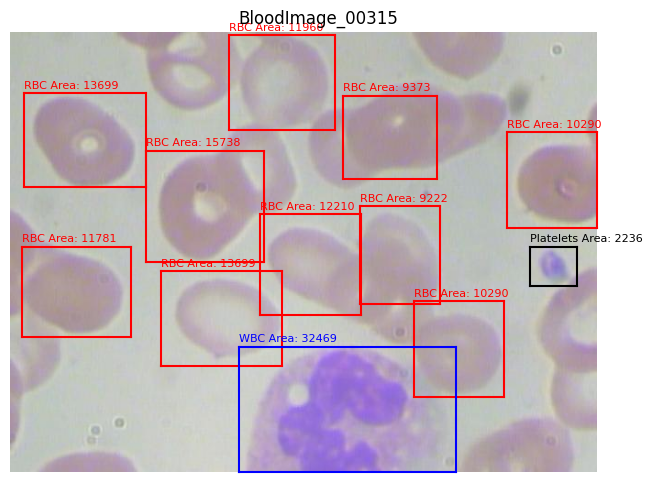

In [100]:
# EDA on cell sizes
from PIL import Image

jpg_dir = '../data/BCCD/JPEGImages/'
jpgs_in_jpg_dir = os.listdir(jpg_dir)
for entry in json_data:
    blood_image_name = list(entry.keys())[0]
    filename = blood_image_name+".jpg"
    filename = os.path.join(jpg_dir, filename)

    print(filename)
    # Load the image
    image = Image.open(filename)

    # Show it
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(blood_image_name)
    # plt.show()
    for key, item in entry[blood_image_name].items():
        try:
            cell_type = entry[blood_image_name][key]['name']
            xmin = entry[blood_image_name][key]['xmin']
            xmax = entry[blood_image_name][key]['xmax']
            ymin = entry[blood_image_name][key]['ymin']
            ymax = entry[blood_image_name][key]['ymax']
            pt1 = (xmin, ymin)
            pt2 = (xmin, ymax)
            pt3 = (xmax, ymin)
            pt4 = (xmax, ymax)
            if cell_type == "RBC":
                color = 'red'
            elif cell_type == "WBC":
                color = "blue"
            else:
                color = "black"
            plt.plot([xmin, xmax],[ymin, ymin], color=color)
            plt.plot([xmax, xmax],[ymin, ymax], color=color)
            plt.plot([xmin, xmax],[ymax, ymax], color=color)
            plt.plot([xmin, xmin],[ymax, ymin], color=color)
            area = (xmax - xmin) * (ymax - ymin)
            plt.text(xmin, ymin - 5, f'{cell_type} Area: {area}', color=color, fontsize=8)
            # break
        except KeyError:
            pass
        print(item)
    break
